### Test stageR (two stage FDR control)

In [1]:
import rpy2.robjects as ro
from rpy2.robjects import pandas2ri, conversion, Formula
import rpy2.robjects.packages as rpackages
from rpy2.robjects.packages import importr

In [3]:
import os
import pickle as pkl
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
import pydeseq2
from pydeseq2.dds import DeseqDataSet
from pydeseq2.default_inference import DefaultInference
from pydeseq2.ds import DeseqStats

In [7]:
from deconveil.dds import deconveil_fit
from deconveil.inference import Inference
from deconveil.default_inference import DefInference
from deconveil.utils_fit import *
from deconveil.utils_processing import *
from deconveil.utils_plot import *
from deconveil import deconveil_fit
from deconveil.ds import deconveil_stats

#### Functions to run PyDESeq2 (CN-naive) & DeConveil (CN-aware)

In [9]:
def run_pydeseq2(rna_counts, 
                 metadata, 
                 output_path, 
                 design="~condition", 
                 alpha=0.05):
    """
    Runs PyDESeq2 analysis and saves the results.

    Parameters:
        rna_counts (pd.DataFrame): Count matrix with genes as rows and samples as columns.
        metadata (pd.DataFrame): Metadata for the samples with design factors.
        output_path (str): Directory to save the results.
        design_factors (str): Column in metadata to use for design.
        alpha (float): Significance level for statistical tests.
    """
    os.makedirs(output_path, exist_ok=True)
    
    # Initialize DESeq2 analysis
    inference = DefaultInference(n_cpus=8)
    dds = DeseqDataSet(
        counts=rna_counts,
        metadata=metadata,
        design_factors=None,  # compare samples based on condition
        refit_cooks=True,
        inference=inference,
    )

    # Fit DESeq2 model
    dds.fit_size_factors()
    dds.fit_genewise_dispersions()
    dds.fit_dispersion_trend()
    dds.fit_dispersion_prior()
    dds.fit_MAP_dispersions()
    dds.fit_LFC()
    dds.calculate_cooks()
    
    if dds.refit_cooks:
        dds.refit()

    # Perform statistical analysis
    stat_res_pydeseq = DeseqStats(dds, 
                                  alpha=alpha, 
                                  cooks_filter=True, 
                                  independent_filter=False, 
                                  contrast=["condition", "B", "A"])
    stat_res_pydeseq.run_wald_test()

    if stat_res_pydeseq.cooks_filter:
        stat_res_pydeseq._cooks_filtering()
    stat_res_pydeseq.p_values

    #if stat_res_pydeseq.independent_filter:
        #stat_res_pydeseq._independent_filtering()
    #else:
        #stat_res_pydeseq._p_value_adjustment()

    # Log-fold change shrinkage
    stat_res_pydeseq.lfc_shrink(coeff="condition[T.B]")
    stat_res_pydeseq.summary()

    # Save results
    results_path = os.path.join(output_path, "res_CNnaive.csv")
    stat_res_pydeseq.results_df.to_csv(results_path)
    return(stat_res_pydeseq.results_df)

In [11]:
def run_deconveil(rna_counts, metadata, cnv, output_path, design="~condition", alpha=0.05):
    """
    Runs DeConveil analysis and saves the results.

    Parameters:
        rna_counts (pd.DataFrame): Count matrix with genes as rows and samples as columns.
        metadata (pd.DataFrame): Metadata for the samples with design factors.
        cnv (pd.DataFrame): Copy number variation (CNV) data matrix  with genes as rows and samples as columns.
        output_path (str): Directory to save the results.
        design_factors (str): Column in metadata to use for design.
        alpha (float): Significance level for statistical tests.
    """
    os.makedirs(output_path, exist_ok=True)
    
    # Initialize DeConveil inference
    inference = DefInference(n_cpus=8)

    # Fit DeConveil model
    dds = deconveil_fit(
        counts=rna_counts,
        metadata=metadata,
        cnv=cnv,
        design_factors="condition",
        inference=inference,
        refit_cooks=True
    )
    dds.fit_size_factors()
    dds.fit_genewise_dispersions()
    dds.fit_dispersion_trend()
    dds.fit_dispersion_prior()
    dds.fit_MAP_dispersions()
    dds.fit_LFC()
    dds.calculate_cooks()

    if dds.refit_cooks:
        dds.refit()  # Replace outlier counts

    # Statistical analysis
    stat_res_deconveil = deconveil_stats(
        dds, 
        alpha=alpha, 
        contrast=["condition", "B", "A"],
        independent_filter=True, 
        cooks_filter=True
    )
    stat_res_deconveil.run_wald_test()

    stat_res_deconveil.p_values

    if stat_res_deconveil.independent_filter:
        stat_res_deconveil._independent_filtering()
    else:
        stat_res_deconveil._p_value_adjustment()

    # Log-fold change shrinkage
    stat_res_deconveil.lfc_shrink(coeff="condition[T.B]")
    stat_res_deconveil.summary()

    # Save results
    results_path = os.path.join(output_path, "res_CNaware.csv")
    stat_res_deconveil.results_df.to_csv(results_path)
    return(stat_res_deconveil.results_df)

#### Load TCGA data

In [13]:
rna_counts = load_test_data(
    modality="rna",
    dataset="tcga_brca",
    debug=False,
)
rna_counts = rna_counts.T

metadata = load_test_data(
    modality="metadata",
    dataset="tcga_brca",
    debug=False,
)

cnv = load_test_data(
    modality="cnv",
    dataset="tcga_brca",
    debug=False,
)
cnv = cnv.T

In [15]:
rna_counts.head()

,A2M,A2M-AS1,A2ML1,A2ML1-AS1,A2MP1,A3GALT2,A4GALT,A4GNT,AACS,AACSP1,...,ZSWIM6,ZSWIM9,ZW10,ZWILCH,ZWINT,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1
GTEX-13PVQ-1026-SM-5KM3M.1,3502210.0,83739.0,1592.0,17369.0,9842.0,4961.0,377148.0,657.0,156623.0,151.0,...,231243.0,11494.0,41101.0,23345.0,4853.0,93143.0,679.0,97130.0,1819661.0,394464.0
GTEX-18QFQ-0826-SM-718AX.1,5394960.0,155914.0,14511.0,10089.0,11023.0,303.0,278056.0,357.0,385961.0,149.0,...,184259.0,83650.0,123117.0,74837.0,25442.0,320704.0,8603.0,300670.0,1580226.0,918922.0
GTEX-1JN6P-2426-SM-ARL99.1,7136304.0,219925.0,2254.0,12267.0,5955.0,769.0,229205.0,0.0,40360.0,0.0,...,114710.0,22251.0,37669.0,17233.0,4141.0,82340.0,372.0,89483.0,982597.0,339959.0
GTEX-13S86-1226-SM-5S2OA.1,5710693.0,236061.0,932.0,4446.0,12644.0,986.0,468005.0,76.0,177527.0,0.0,...,62143.0,22458.0,73701.0,20962.0,8415.0,111953.0,126.0,94875.0,1060350.0,233669.0
GTEX-132NY-0826-SM-5K7Y7.1,4020951.0,155161.0,6312.0,5744.0,5015.0,76.0,480082.0,1286.0,277306.0,152.0,...,106252.0,28196.0,49946.0,35748.0,6204.0,134309.0,505.0,133562.0,1136263.0,392324.0


In [17]:
metadata.head()

,condition
GTEX-13PVQ-1026-SM-5KM3M.1,A
GTEX-18QFQ-0826-SM-718AX.1,A
GTEX-1JN6P-2426-SM-ARL99.1,A
GTEX-13S86-1226-SM-5S2OA.1,A
GTEX-132NY-0826-SM-5K7Y7.1,A


In [19]:
cnv.head()

,A2M,A2M-AS1,A2ML1,A2ML1-AS1,A2MP1,A3GALT2,A4GALT,A4GNT,AACS,AACSP1,...,ZSWIM6,ZSWIM9,ZW10,ZWILCH,ZWINT,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1
GTEX-13PVQ-1026-SM-5KM3M.1,2,2,2,2,2,2,2,2,2,2,...,2,2,2,2,2,2,2,2,2,2
GTEX-18QFQ-0826-SM-718AX.1,2,2,2,2,2,2,2,2,2,2,...,2,2,2,2,2,2,2,2,2,2
GTEX-1JN6P-2426-SM-ARL99.1,2,2,2,2,2,2,2,2,2,2,...,2,2,2,2,2,2,2,2,2,2
GTEX-13S86-1226-SM-5S2OA.1,2,2,2,2,2,2,2,2,2,2,...,2,2,2,2,2,2,2,2,2,2
GTEX-132NY-0826-SM-5K7Y7.1,2,2,2,2,2,2,2,2,2,2,...,2,2,2,2,2,2,2,2,2,2


#### QC check and filtering

In [21]:
print("Before filtering:", rna_counts.shape, cnv.shape, metadata.shape)
# Reorder cnv to match rna_counts
cnv = cnv.loc[rna_counts.index]
assert (rna_counts.index == metadata.index).all(), "Sample order mismatch between rna_counts and metadata"
assert (cnv.index == rna_counts.index).all(), "Sample order mismatch between cnv and rna_counts"

Before filtering: (400, 17387) (400, 17387) (400, 1)


In [23]:
all_zero_mask = (rna_counts.sum(axis=0) == 0)
print("All-zero genes:", all_zero_mask.sum())
rna_counts = rna_counts.loc[:, ~all_zero_mask]
cnv = cnv.loc[:, ~all_zero_mask]  

All-zero genes: 0


In [25]:
res = filter_low_count_genes(rna_counts, other_dfs=[cnv], min_count=300, min_samples=50)
rna_counts = res["filtered_df"]
cnv = res["other_filtered"][0]
print("After low-count filtering:", rna_counts.shape, cnv.shape)

After low-count filtering: (400, 16252) (400, 16252)


#### Run PyDESeq2 (CN-naive) and DeConveil (CN-aware) methods

In [27]:
# PyDESeq2
pydeseq2_output_path = "/Users/katsiarynadavydzenka/Documents/PhD_AI/TCGA_test/results/BRCA/stageR"
res_pydeseq = run_pydeseq2(rna_counts, metadata, pydeseq2_output_path)

Fitting size factors...


Using None as control genes, passed at DeseqDataSet initialization


... done in 0.24 seconds.

Fitting dispersions...
... done in 5.04 seconds.

Fitting dispersion trend curve...
... done in 0.35 seconds.

Fitting MAP dispersions...
... done in 5.31 seconds.

Fitting LFCs...
... done in 2.51 seconds.

Calculating cook's distance...
... done in 0.73 seconds.

Replacing 1590 outlier genes.

Fitting dispersions...
... done in 0.35 seconds.

Fitting MAP dispersions...
... done in 0.51 seconds.

Fitting LFCs...
... done in 0.50 seconds.

Running Wald tests...
... done in 0.90 seconds.

Fitting MAP LFCs...


Log2 fold change & Wald test p-value: condition B vs A
               baseMean  log2FoldChange     lfcSE       stat         pvalue  \
A2M        5.180468e+06       -0.812598  0.090506  -8.050406   8.251979e-16   
A2M-AS1    1.578345e+05       -0.855286  0.100089  -8.690593   3.605531e-18   
A2ML1      6.185229e+04        4.950652  0.222363  22.380639  6.076767e-111   
A2ML1-AS1  7.217329e+03       -2.495263  0.094391 -26.506381  8.182245e-155   
A2MP1      7.994097e+03       -1.525349  0.091739 -23.551071  1.224020e-122   
...                 ...             ...       ...        ...            ...   
ZXDC       2.017188e+05       -0.372003  0.038688  -9.534362   1.508097e-21   
ZYG11A     2.195483e+04        2.988504  0.162993  18.433486   7.077253e-76   
ZYG11B     2.067749e+05        0.266726  0.042752   6.411424   1.441666e-10   
ZYX        1.429673e+06       -0.714669  0.062446 -11.762887   6.062546e-32   
ZZEF1      4.326109e+05       -0.884217  0.042972 -19.986909   7.159510e-89 

... done in 4.48 seconds.



In [29]:
res_pydeseq.head()

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
A2M,5.180468e+06,-0.812598,0.090506,-8.050406,8.251979e-16,1.518985e-15
A2M-AS1,1.578345e+05,-0.855286,0.100089,-8.690593,3.605531e-18,7.038689e-18
A2ML1,6.185229e+04,4.950652,0.222363,22.380639,6.076767e-111,5.608156e-110
A2ML1-AS1,7.217329e+03,-2.495263,0.094391,-26.506381,8.182245e-155,1.299881e-153
A2MP1,7.994097e+03,-1.525349,0.091739,-23.551071,1.224020e-122,1.315659e-121


In [31]:
# DeConveil
deconveil_output_path = "/Users/katsiarynadavydzenka/Documents/PhD_AI/TCGA_test/results/BRCA/stageR"
res_deconveil = run_deconveil(rna_counts, metadata, cnv, deconveil_output_path)  

/var/folders/mh/vvy722dj18x7xj41n2qbdzs80000gn/T/ipykernel_2652/3232471129.py:19: DeprecationWarning: design_factors are deprecated and will soon be removedPlease consider providing a formulaic formula using the design argument instead
  dds = deconveil_fit(
Fitting size factors...
... done in 0.18 seconds.



Using None as control genes, passed at deconveil_fit initialization


Fitting dispersions...
... done in 5.13 seconds.

Fitting dispersion trend curve...
... done in 0.29 seconds.

Fitting MAP dispersions...
... done in 5.45 seconds.

Fitting LFCs...
... done in 3.91 seconds.

Calculating cook's distance...
... done in 0.77 seconds.

Replacing 1527 outlier genes.



replace_mask before filtering: (400, 1527)
Number of True values in replace_mask: 3214
replacement_counts_trimmed shape: (330, 1527)


Fitting dispersions...
... done in 0.57 seconds.

Fitting MAP dispersions...
... done in 0.34 seconds.

Fitting LFCs...
... done in 0.22 seconds.

Running Wald tests...
... done in 0.76 seconds.

Fitting MAP LFCs...


Log2 fold change & Wald test p-value: condition B vs A
               baseMean  log2FoldChange     lfcSE       stat         pvalue  \
A2M        5.180468e+06        0.957425  0.031210 -14.988443   8.737744e-51   
A2M-AS1    1.420233e+05       -0.541178  0.041925 -23.760590  8.539806e-125   
A2ML1      6.185229e+04        4.655787  0.161408  18.594476   3.561792e-77   
A2ML1-AS1  7.217329e+03       -3.054144  0.095731 -33.742061  1.397848e-249   
A2MP1      7.543297e+03       -1.850092  0.051026 -21.345796  4.266352e-101   
...                 ...             ...       ...        ...            ...   
ZXDC       2.017188e+05        0.857961  0.045391 -27.202825  6.013908e-163   
ZYG11A     2.195483e+04        3.200862  0.152659  15.115381   1.282266e-51   
ZYG11B     2.067749e+05        1.527058  0.047877  -5.006991   5.528740e-07   
ZYX        1.429673e+06        0.893022  0.040140 -22.563870  9.815028e-113   
ZZEF1      4.326109e+05        1.218407  0.047775 -25.281372  5.120157e-141 

... done in 3.88 seconds.



In [33]:
# Extact p-values from PyDESeq2 and Deconveil results fit

p_naive = res_pydeseq["pvalue"].astype(float)
p_aware = res_deconveil["pvalue"].astype(float)
p_naive

A2M           8.251979e-16
A2M-AS1       3.605531e-18
A2ML1        6.076767e-111
A2ML1-AS1    8.182245e-155
A2MP1        1.224020e-122
                 ...      
ZXDC          1.508097e-21
ZYG11A        7.077253e-76
ZYG11B        1.441666e-10
ZYX           6.062546e-32
ZZEF1         7.159510e-89
Name: pvalue, Length: 16252, dtype: float64

In [35]:
p_aware

A2M           8.737744e-51
A2M-AS1      8.539806e-125
A2ML1         3.561792e-77
A2ML1-AS1    1.397848e-249
A2MP1        4.266352e-101
                 ...      
ZXDC         6.013908e-163
ZYG11A        1.282266e-51
ZYG11B        5.528740e-07
ZYX          9.815028e-113
ZZEF1        5.120157e-141
Name: pvalue, Length: 16252, dtype: float64

#### Run stageR

In [37]:
res_screen, res_confirm, res_pydeseq_upd, res_deconveil_upd = run_stageR(res_pydeseq, res_deconveil)
print(res_screen.head())
print(res_confirm.head())
print(res_pydeseq_upd.head())
print(res_deconveil_upd.head())

R callback write-console: Caricamento del pacchetto richiesto: SummarizedExperiment
  
R callback write-console: Caricamento del pacchetto richiesto: MatrixGenerics
  
R callback write-console: Caricamento del pacchetto richiesto: matrixStats
  
R callback write-console: 
Caricamento pacchetto: ‘MatrixGenerics’

  
R callback write-console: I seguenti oggetti sono mascherati da ‘package:matrixStats’:

    colAlls, colAnyNAs, colAnys, colAvgsPerRowSet, colCollapse,
    colCounts, colCummaxs, colCummins, colCumprods, colCumsums,
    colDiffs, colIQRDiffs, colIQRs, colLogSumExps, colMadDiffs,
    colMads, colMaxs, colMeans2, colMedians, colMins, colOrderStats,
    colProds, colQuantiles, colRanges, colRanks, colSdDiffs, colSds,
    colSums2, colTabulates, colVarDiffs, colVars, colWeightedMads,
    colWeightedMeans, colWeightedMedians, colWeightedSds,
    colWeightedVars, rowAlls, rowAnyNAs, rowAnys, rowAvgsPerColSet,
    rowCollapse, rowCounts, rowCummaxs, rowCummins, rowCumprods,
    row

              padjScreen        p_naive        p_aware
A2M         4.384926e-50   8.388239e-16   8.882025e-51
A2M-AS1    1.148440e-123   3.665067e-18  8.680819e-125
A2ML1      6.984414e-110  6.177109e-111   3.620605e-77
A2ML1-AS1  6.556373e-248  8.317353e-155  1.420930e-249
A2MP1      1.605550e-121  1.244231e-122  4.336800e-101
           padjScreen  p_naive  p_aware
A2M               1.0      1.0      1.0
A2M-AS1           1.0      1.0      1.0
A2ML1             1.0      1.0      1.0
A2ML1-AS1         1.0      1.0      1.0
A2MP1             1.0      1.0      1.0
               baseMean  log2FoldChange     lfcSE       stat         pvalue  \
A2M        5.180468e+06       -0.812598  0.090506  -8.050406   8.251979e-16   
A2M-AS1    1.578345e+05       -0.855286  0.100089  -8.690593   3.605531e-18   
A2ML1      6.185229e+04        4.950652  0.222363  22.380639  6.076767e-111   
A2ML1-AS1  7.217329e+03       -2.495263  0.094391 -26.506381  8.182245e-155   
A2MP1      7.994097e+03       -1.52

In [ ]:
# gene-class assignment using res_confirm

def classify_gene_stageR(row):
    # Not screened → not classifiable
    if pd.isna(row["DE_naive_confirmed"]) and pd.isna(row["DE_aware_confirmed"]):
        return "NEUTRAL"

    if row["DE_naive_confirmed"] == 0 and row["DE_aware_confirmed"] == 1:
        return "DCG"

    if row["DE_naive_confirmed"] == 1 and row["DE_aware_confirmed"] == 0:
        return "DSG"

    if row["DE_naive_confirmed"] == 1 and row["DE_aware_confirmed"] == 1:
        return "DIG"

    return "NEUTRAL"

In [81]:
summary = pd.DataFrame({
    "naive": res_pydeseq_upd["DE_confirmed"].value_counts(dropna=False),
    "aware": res_deconveil_upd["DE_confirmed"].value_counts(dropna=False)
})
summary

,naive,aware
DE_confirmed,,
1.0,14264,14511
0.0,1988,1741


In [87]:
# Comapare two-stage (naïve BH) and the hierarchical (stageR) approaches

df = pd.DataFrame({
    "gene": res_pydeseq_upd.index,
    "padj_naive_BH": res_pydeseq_upd["padj"],
    "padj_naive_stageR": res_pydeseq_upd["padj_stageR"],
    "padj_paware_BH": res_deconveil_upd["padj"],
    "padj_paware_stageR": res_deconveil_upd["padj_stageR"],
    "DE_conf_naive": res_pydeseq_upd["DE_confirmed"],
    "DE_conf_aware": res_deconveil_upd["DE_confirmed"]
}).set_index("gene")
df

,padj_naive_BH,padj_naive_stageR,padj_paware_BH,padj_paware_stageR,DE_conf_naive,DE_conf_aware
gene,,,,,,
A2M,1.518985e-15,8.388239e-16,2.982063e-50,8.882025e-51,1.0,1.0
A2M-AS1,7.038689e-18,3.665067e-18,7.433794e-124,8.680819e-125,1.0,1.0
A2ML1,5.608156e-110,6.177109e-111,1.758391e-76,3.620605e-77,1.0,1.0
A2ML1-AS1,1.299881e-153,8.317353e-155,3.937233e-248,1.420930e-249,1.0,1.0
A2MP1,1.315659e-121,1.244231e-122,2.855715e-100,4.336800e-101,1.0,1.0
...,...,...,...,...,...,...
ZXDC,3.182237e-21,1.532999e-21,7.888461e-162,6.113212e-163,1.0,1.0
ZYG11A,3.947135e-75,7.194115e-76,4.446212e-51,1.303440e-51,1.0,1.0
ZYG11B,2.292111e-10,1.465472e-10,7.576784e-07,5.620033e-07,1.0,1.0


In [91]:
# CN-naive
alpha = 0.05
df["sig_BH"] = df["padj_naive_BH"] < alpha
df["sig_stageR"] = df["DE_conf_naive"] == 1

summary = pd.crosstab(df["sig_BH"], df["sig_stageR"])

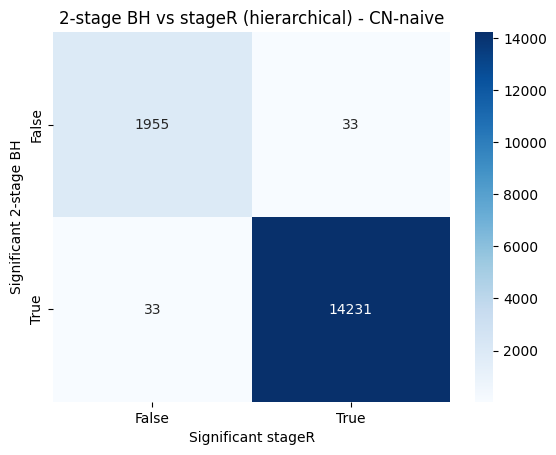

In [93]:
sns.heatmap(summary, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Significant stageR")
plt.ylabel("Significant 2-stage BH")
plt.title("2-stage BH vs stageR (hierarchical) - CN-naive")
plt.show()

In [97]:
# CN-aware
alpha = 0.05
df["sig_BH"] = df["padj_paware_BH"] < alpha
df["sig_stageR"] = df["DE_conf_aware"] == 1

summary = pd.crosstab(df["sig_BH"], df["sig_stageR"])

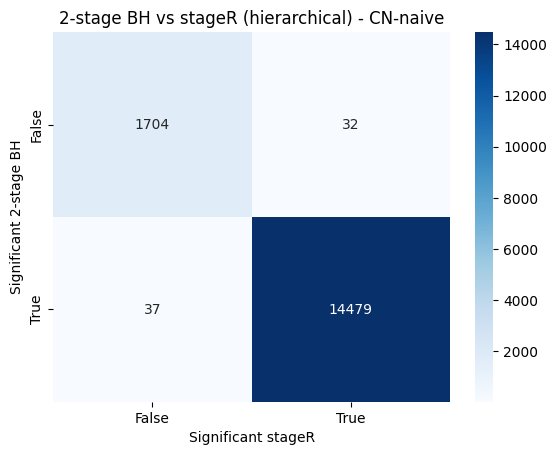

In [99]:
sns.heatmap(summary, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Significant stageR")
plt.ylabel("Significant 2-stage BH")
plt.title("2-stage BH vs stageR (hierarchical) - CN-naive")
plt.show()

In [101]:
# overall
df["sig_BH"] = (df["padj_naive_BH"] < alpha) & (df["padj_paware_BH"] < alpha)
df["sig_stageR"] = (df["DE_conf_naive"] == 1) & (df["DE_conf_aware"] == 1)

summary = pd.crosstab(df["sig_BH"], df["sig_stageR"])

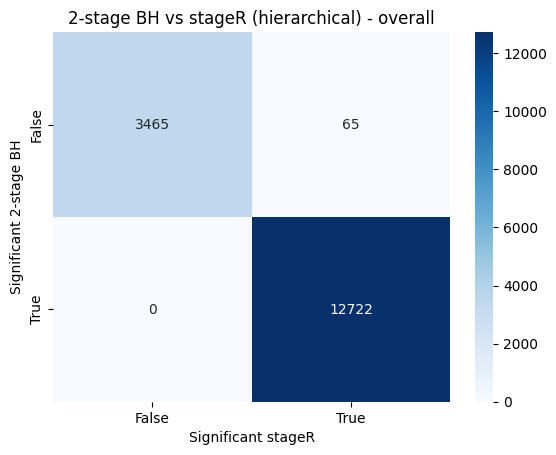

In [103]:
sns.heatmap(summary, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Significant stageR")
plt.ylabel("Significant 2-stage BH")
plt.title("2-stage BH vs stageR (hierarchical) - overall")
plt.show()

In [81]:
res1_df.to_csv("/Users/katsiarynadavydzenka/Documents/PhD_AI/deconveilCaseStudies/revision/stageR_test/res1.csv", index=True)
res2_df.to_csv("/Users/katsiarynadavydzenka/Documents/PhD_AI/deconveilCaseStudies/revision/stageR_test/res2.csv", index=True)
res_pydeseq_updated.to_csv("/Users/katsiarynadavydzenka/Documents/PhD_AI/deconveilCaseStudies/revision/stageR_test/res_CNnaive.csv", index=True)
res_deconveil_updated.to_csv("/Users/katsiarynadavydzenka/Documents/PhD_AI/deconveilCaseStudies/revision/stageR_test/res_CNaware.csv", index=True)